# Cell 1: Import necessary libraries for data processing and signal analysis

In [1]:
import os
import pandas as pd
import numpy as np
import mne
from scipy.stats import skew, kurtosis, entropy
from scipy.signal import welch

# Cell 2: Define helper functions for signal filtering and transformation

In [2]:
def bandpower(data, sf, band):
    """
    Calculate the absolute bandpower of a signal using Welch's method.
    """
    band = np.asarray(band)
    low, high = band
    
    # Calculate Power Spectral Density (PSD) using Welch's method
    freqs, psd = welch(data, sf, nperseg=int(sf*2)) 
    
    # Find intersecting values in the frequency vector
    idx_band = np.logical_and(freqs >= low, freqs <= high)
    
    bp = np.trapezoid(psd[idx_band], freqs[idx_band])
    return bp

def create_epochs_and_normalize(signal, samples_per_epoch):
    """
    Split the continuous signal into 30-second epochs and apply independent Z-score normalization.
    """
    epochs = []
    total_samples = len(signal)
    
    for start in range(0, total_samples, samples_per_epoch):
        end = start + samples_per_epoch
        epoch_data = signal[start:end]
        
        if len(epoch_data) < samples_per_epoch:
            pad_length = samples_per_epoch - len(epoch_data)
            epoch_data = np.pad(epoch_data, (0, pad_length), mode='reflect')
            
        # Independent Z-score normalization for each epoch
        epoch_mean = np.mean(epoch_data)
        epoch_std = np.std(epoch_data)
        if epoch_std > 0:
            epoch_data = (epoch_data - epoch_mean) / epoch_std
        else:
            epoch_data = epoch_data - epoch_mean 
            
        epochs.append(epoch_data)
    return np.array(epochs)

def spectral_entropy(psd, normalize=True):
    psd_norm = psd / np.sum(psd) 
    se = entropy(psd_norm)
    if normalize:
        se /= np.log2(len(psd_norm))
    return se

def calc_rolling_feature(epoch, sfreq, window_sec=2):
    window_size = int(sfreq * window_sec)
    rolling_rms = pd.Series(epoch).rolling(window=window_size).apply(lambda x: np.sqrt(np.mean(x**2)), raw=True)
    return np.nanvar(rolling_rms)

# Cell 3: Define the core function to process a single EDF and TSV file pair

In [3]:
def process_single_file(edf_path, tsv_path):
    """
    Process a single subject: Read data -> Epoch -> Extract Features -> Assign Labels.
    Returns the Feature matrix (X) and Label array (y).
    """
    # 1. Load raw data and apply band-pass filter 
    raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False) 
    raw.pick(['EEG C3-M2']) 
    raw.load_data()         
    raw.filter(l_freq=0.5, h_freq=30.0, verbose=False)
    
    annotations_df = pd.read_csv(tsv_path, sep='\t')
    
    # 2. Epoching and Normalization (30 seconds per epoch)
    sfreq = raw.info['sfreq']
    samples_per_epoch = int(sfreq * 30) 
    data = raw.get_data()[0]
    epochs_array = create_epochs_and_normalize(data, samples_per_epoch)
    
    # 3. Label Encoding (Single-label mapping for easier sharing and model training)
    ann2label = {
        "Sleep stage W": 0, 
        "Sleep stage N1": 1, 
        "Sleep stage N2": 2, 
        "Sleep stage N3": 3, 
        "Sleep stage R": 4,
    }
    
    # Initialize labels with -1 (Unlabeled/Unknown state)
    y = np.full(len(epochs_array), -1) 
    
    for index, row in annotations_df.iterrows():
        desc = row['description']
        if desc in ann2label:
            start_ep = int(row['onset'] // 30)
            end_ep = int((row['onset'] + row['duration']) // 30)
            
            for ep_idx in range(start_ep, end_ep + 1):
                if ep_idx < len(epochs_array):
                    y[ep_idx] = ann2label[desc]
    
    # 4. Feature Extraction (Time domain and Frequency domain, Entropy, Ratio, Rolling )
    features = []
    for epoch in epochs_array:
        freqs, psd = welch(epoch, sfreq, nperseg=int(sfreq*2))
        
        # features in time domain
        mean_v = np.mean(epoch)
        var_v = np.var(epoch)
        skew_v = skew(epoch)
        kurt_v = kurtosis(epoch)
        
        # Band powers
        dp = bandpower(epoch, sfreq, [0.5, 4])   # Delta
        tp = bandpower(epoch, sfreq, [4, 8])     # Theta
        ap = bandpower(epoch, sfreq, [8, 13])    # Alpha
        bp = bandpower(epoch, sfreq, [13, 30])   # Beta
        
        # --- Entropy, Ratio, Rolling ---
        
        # 1. Ratio (Theta / Alpha) 
        theta_alpha_ratio = tp / (ap + 1e-6)
        
        # 2. Spectral Entropy
        spec_entropy = spectral_entropy(psd[freqs <= 30]) # Chỉ tính entropy dải 0-30Hz
        
        # 3. Rolling Variance 
        roll_var = calc_rolling_feature(epoch, sfreq, window_sec=2)
        
        # Vector
        features.append([
            mean_v, var_v, skew_v, kurt_v, 
            dp, tp, ap, bp, 
            theta_alpha_ratio, spec_entropy, roll_var
        ])
    
    X = np.array(features)
    
    # Filter out unlabeled epochs (where y == -1) to keep the dataset clean
    valid_indices = y != -1
    return X[valid_indices], y[valid_indices]

# Cell 4: Define the batch processing function to handle multiple patients

In [4]:
def process_all_datasets(input_folder, output_folder):
    """
    Iterate through all files in the input directory, process them sequentially, 
    and save the aggregated dataset to a CSV file.
    """
    all_X = []
    all_y = []
    
    print("Starting batch processing...")
    
    # Loop through all files in the designated input folder
    for filename in os.listdir(input_folder):
        if filename.endswith(".edf"):
            base_name = filename.replace(".edf", "")
            edf_path = os.path.join(input_folder, filename)
            tsv_path = os.path.join(input_folder, base_name + ".tsv") 
            
            # Check if both EDF and TSV exist before processing
            if os.path.exists(tsv_path):
                print(f"Processing file: {base_name}")
                try:
                    X_file, y_file = process_single_file(edf_path, tsv_path)
                    all_X.append(X_file)
                    all_y.append(y_file)
                except Exception as e:
                    print(f"Error processing {base_name}: {e}")
    
    # Concatenate all subjects' data into a single master array
    X_final = np.vstack(all_X)
    y_final = np.concatenate(all_y)
    
    # Convert to Pandas DataFrame for easy distribution and sharing
    feature_cols = [
        'Mean', 'Variance', 'Skewness', 'Kurtosis', 
        'Power_Delta', 'Power_Theta', 'Power_Alpha', 'Power_Beta',
        'Theta_Alpha_Ratio', 'Spectral_Entropy', 'Rolling_Var'  
    ]
    df = pd.DataFrame(X_final, columns=feature_cols)
    df['Label'] = y_final
    
    # Ensure the output directory exists
    os.makedirs(output_folder, exist_ok=True)
    
    # Export the final compiled dataset as a CSV file
    output_path = os.path.join(output_folder, "all_subjects_features.csv")
    df.to_csv(output_path, index=False)
    
    print(f"\nProcessing complete! Final dataset saved to: {output_path}")
    print(f"Total number of epochs collected: {len(df)}")

# Cell 5: Setup paths and execute the pipeline

In [ ]:
# Define input (raw data) and output (processed data) directories
input_dir = r"Dataset"
output_dir = r"Processed_Data"

# Run the batch processing function
process_all_datasets(input_dir, output_dir)

Starting batch processing...
Processing file: 10000_17728
Reading 0 ... 9109503  =      0.000 ... 35583.996 secs...
Processing file: 10003_26038
Reading 0 ... 10457087  =      0.000 ... 40847.996 secs...
Processing file: 10006_20647
Reading 0 ... 9920511  =      0.000 ... 38751.996 secs...
Processing file: 10009_25600
Reading 0 ... 20446207  =      0.000 ... 39933.998 secs...
Processing file: 10012_22912
Reading 0 ... 9966591  =      0.000 ... 38931.996 secs...
Processing file: 10015_10063
Reading 0 ... 8727551  =      0.000 ... 34091.996 secs...
Processing file: 10018_22795
Reading 0 ... 7820287  =      0.000 ... 30547.996 secs...
Processing file: 10030_16192
Reading 0 ... 8776703  =      0.000 ... 34283.996 secs...
Processing file: 10033_16222
Reading 0 ... 18319359  =      0.000 ... 35779.998 secs...
Processing file: 10036_20251
Reading 0 ... 10469375  =      0.000 ... 40895.996 secs...
Processing file: 10048_24622
Reading 0 ... 10103807  =      0.000 ... 39467.996 secs...
Processin

# Cell data usage guide (Sample)

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

csv_path = "Processed_Data/all_subjects_features.csv"
df = pd.read_csv(csv_path)


label_counts = df['Label'].value_counts()

valid_labels = label_counts[label_counts >= 2].index
df_filtered = df[df['Label'].isin(valid_labels)]

X = df_filtered.drop(columns=['Label'])
y = df_filtered['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

Kích thước tập Train: (13420, 11)
Kích thước tập Test: (3356, 11)


=== SAMPLE COUNT BY LABEL ===
N2: 6063 epochs (36.14%)
N3: 4252 epochs (25.35%)
Wake (W): 3176 epochs (18.93%)
REM: 2594 epochs (15.46%)
N1: 691 epochs (4.12%)


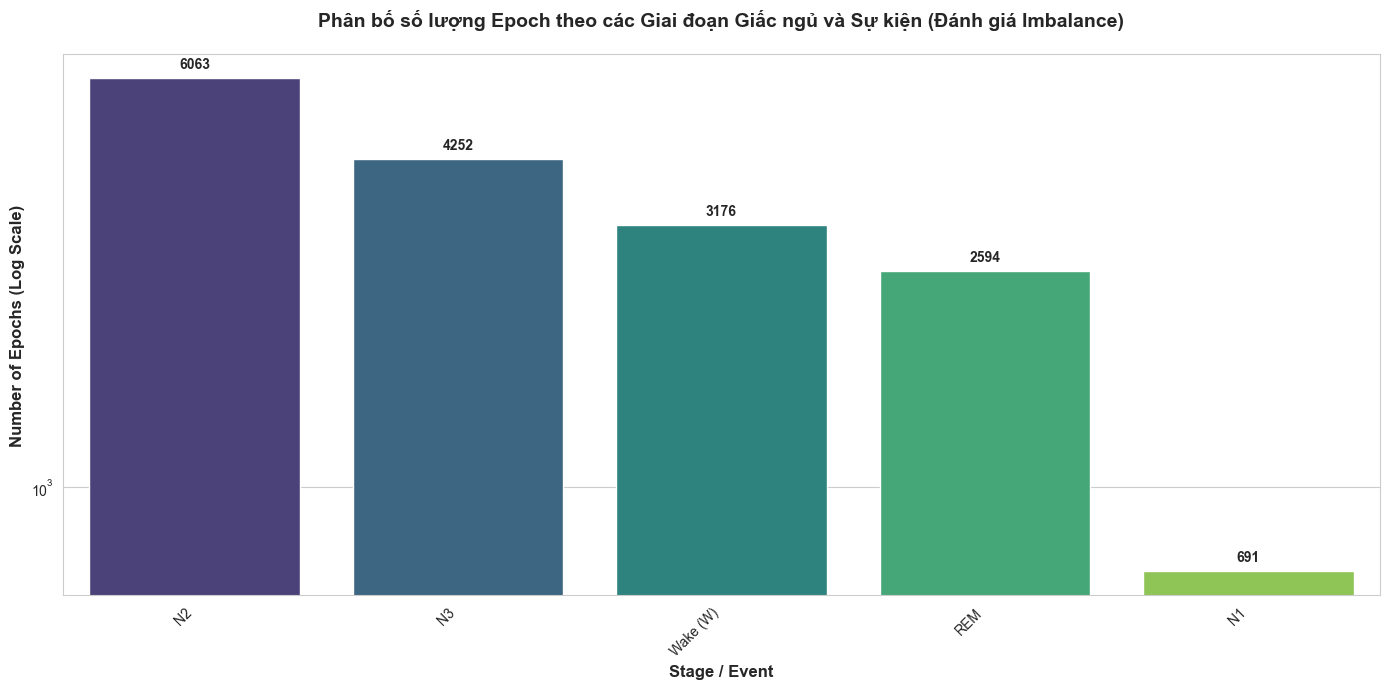

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Processed_Data/all_subjects_features.csv")

# 2. Map label indices to names for readability
label_mapping = {
    0: "Wake (W)", 1: "N1", 2: "N2", 3: "N3", 4: "REM",
    5: "Unknown (?)", 6: "EEG Arousal", 7: "O2 Desat",
    8: "Obs. Apnea", 9: "Ctrl. Apnea", 10: "Mixed Apnea",
    11: "Hypopnea", 12: "Limb Mvmt"
}

# Create label name column (unmapped values become 'Other')
df['Label_Name'] = df['Label'].map(label_mapping).fillna('Other')

# 3. Count samples per label
label_counts = df['Label_Name'].value_counts()

# Print text summary
print("=== SAMPLE COUNT BY LABEL ===")
total = len(df)
for label, count in label_counts.items():
    print(f"{label}: {count} epochs ({(count/total)*100:.2f}%)")
print("=" * 40)

# 4. Visualize with Barplot
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Draw plot
ax = sns.barplot(x=label_counts.index, y=label_counts.values, hue=label_counts.index, palette="viridis", legend=False)

# Annotate counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontweight='bold',
                fontsize=10)

plt.title("Phân bố số lượng Epoch theo các Giai đoạn Giấc ngủ và Sự kiện (Đánh giá Imbalance)", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Stage / Event", fontsize=12, fontweight='bold')
plt.ylabel("Number of Epochs (Log Scale)", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Use log scale for Y-axis to better visualize minority classes
plt.yscale('log')

plt.tight_layout()
plt.show()